# Wine Quality (Chemical Profiling)

##### Dataset: read_csv('winequality-red.csv')

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('winequality-red.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### Checking Missing Values and Duplicate Rows

In [8]:
print(df.isnull().sum()) 
print("Total missing values:", df.isnull().sum().sum()) 
print("Duplicate rows:", df.duplicated().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Total missing values: 0
Duplicate rows: 240


### Removing Duplicate Rows

In [9]:
df.drop_duplicates(keep='first', inplace=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### Formatting Feature Values

In [10]:
df["chlorides"] = df["chlorides"].round(3)
df["density"] = df["density"].round(4)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.9965,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.9949,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.9951,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.9955,3.57,0.71,10.2,5


### Feature Distribution Analysis

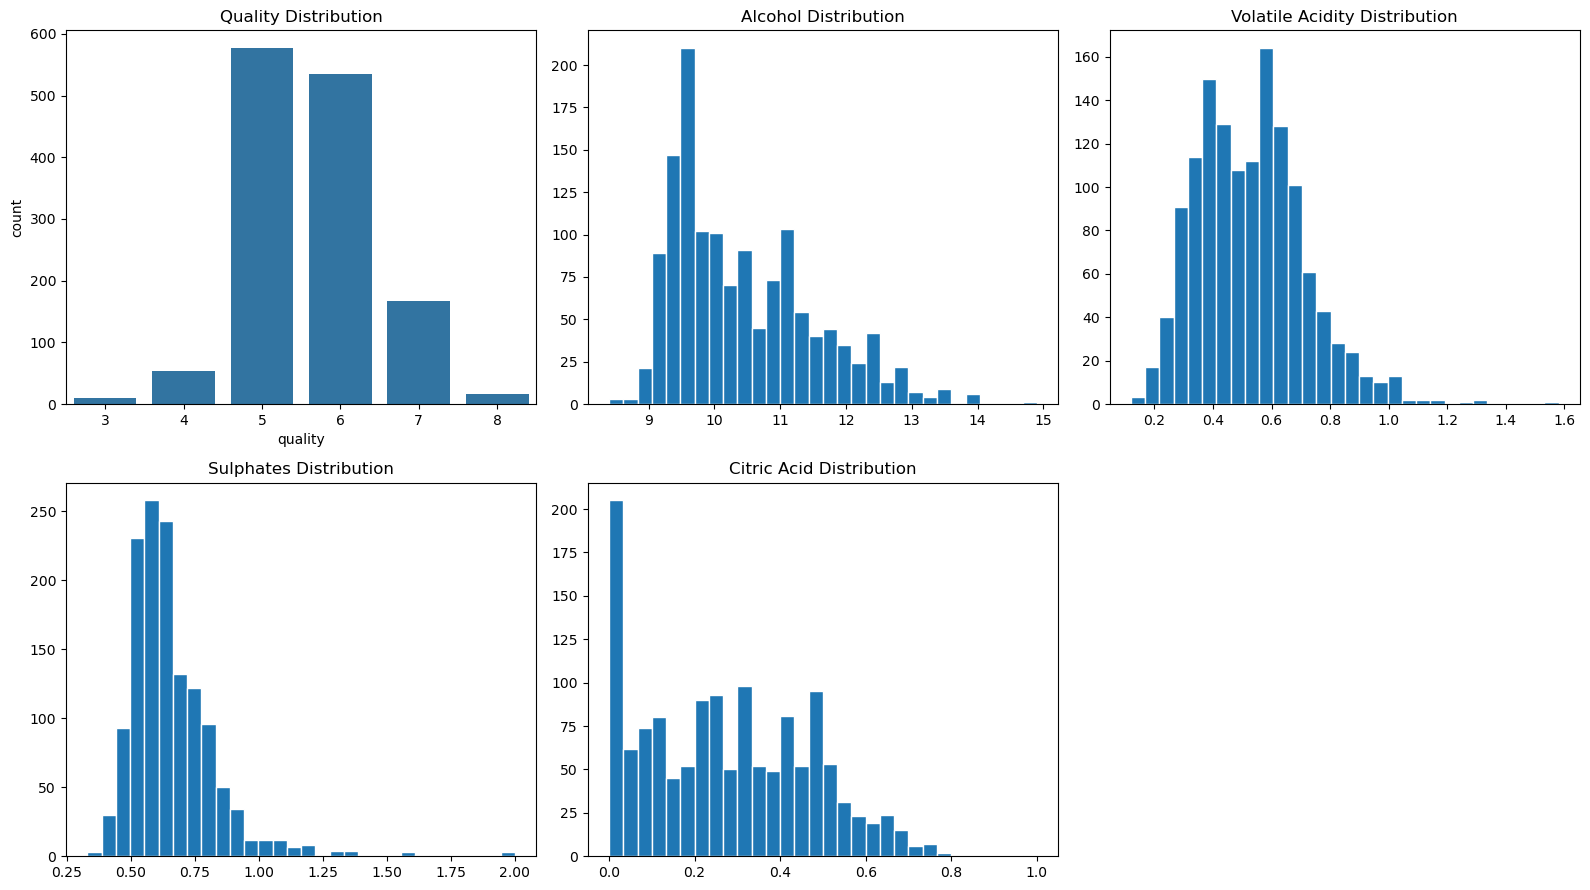

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=df, x='quality', ax=axes[0][0])
axes[0][0].set_title('Quality Distribution')

axes[0][1].hist(df['alcohol'], bins=30, edgecolor='white')
axes[0][1].set_title('Alcohol Distribution')

axes[0][2].hist(df['volatile acidity'], bins=30, edgecolor='white')
axes[0][2].set_title('Volatile Acidity Distribution')

axes[1][0].hist(df['sulphates'], bins=30, edgecolor='white')
axes[1][0].set_title('Sulphates Distribution')

axes[1][1].hist(df['citric acid'], bins=30, edgecolor='white')
axes[1][1].set_title('Citric Acid Distribution')

axes[1][2].set_visible(False) 

plt.tight_layout()
plt.show()

##### Most wines have quality scores of 5 or 6, so the dataset mainly contains medium-quality wines. Alcohol is mostly around 9% to 12%, while volatile acidity, sulphates, and citric acid show different ranges. This plot helps us understand the basic pattern of the data before deeper analysis.

### Comparing Wine Quality with Chemical Features

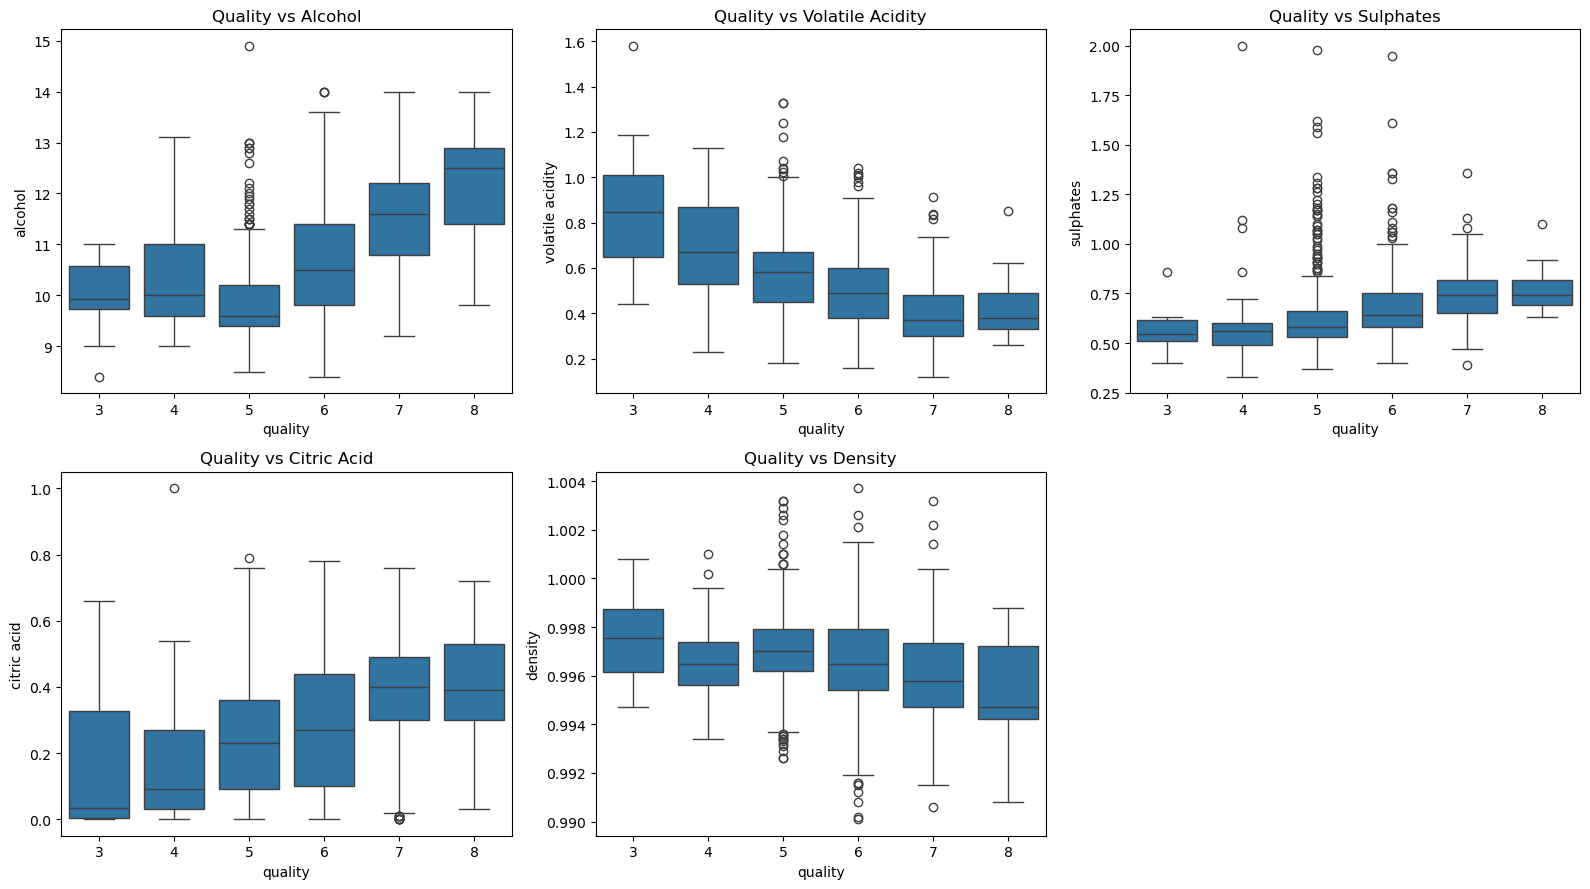

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.boxplot(data=df, x='quality', y='alcohol', ax=axes[0][0])
axes[0][0].set_title('Quality vs Alcohol')

sns.boxplot(data=df, x='quality', y='volatile acidity', ax=axes[0][1])
axes[0][1].set_title('Quality vs Volatile Acidity')

sns.boxplot(data=df, x='quality', y='sulphates', ax=axes[0][2])
axes[0][2].set_title('Quality vs Sulphates')

sns.boxplot(data=df, x='quality', y='citric acid', ax=axes[1][0])
axes[1][0].set_title('Quality vs Citric Acid')

sns.boxplot(data=df, x='quality', y='density', ax=axes[1][1])
axes[1][1].set_title('Quality vs Density')

axes[1][2].set_visible(False)

plt.tight_layout()
plt.show()

##### These boxplots show how wine quality changes with different features. Higher-quality wines usually have higher alcohol, lower volatile acidity, and slightly higher sulphates and citric acid. Density becomes a little lower for better-quality wines. Overall, alcohol and volatile acidity show the clearest relationship with wine quality.

### Correlation Heatmap of Wine Features

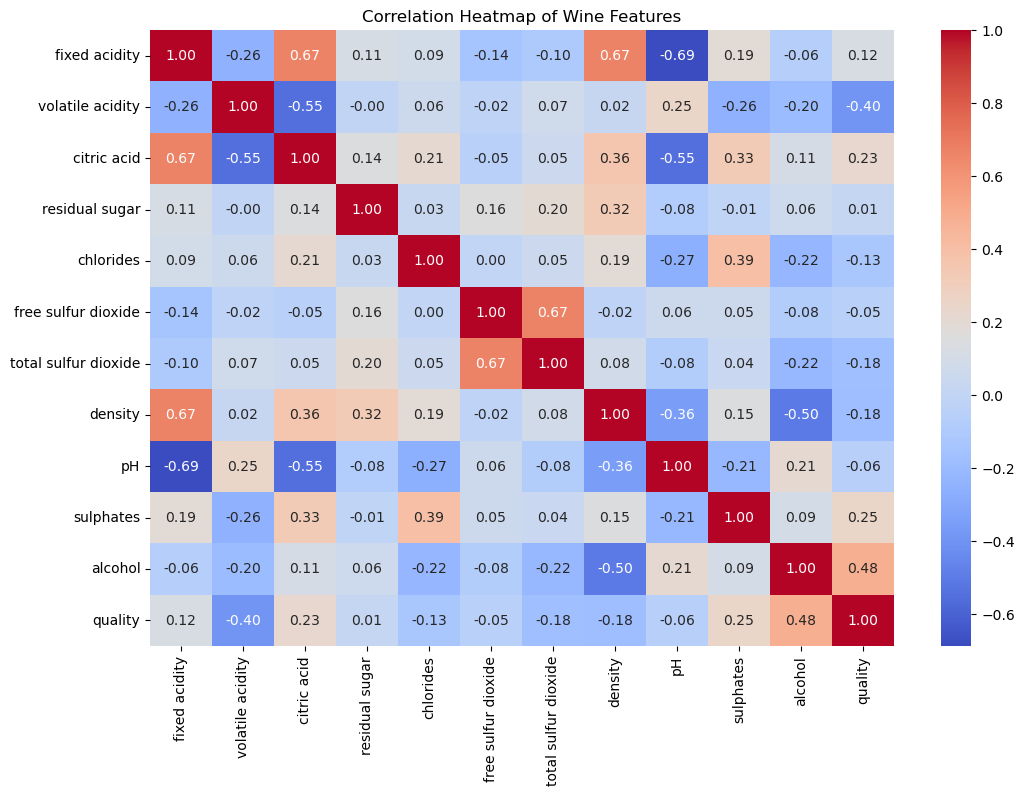

In [53]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Wine Features')
plt.show()

##### This heatmap shows the relationship between wine features and quality. Alcohol has the strongest positive relationship with quality, meaning higher alcohol often links to better wine quality. Volatile acidity has a negative relationship, meaning higher volatile acidity usually links to lower quality. Sulphates and citric acid have small positive effects, while residual sugar has almost no relationship with quality.

### Pairplot of Important Wine Quality Features

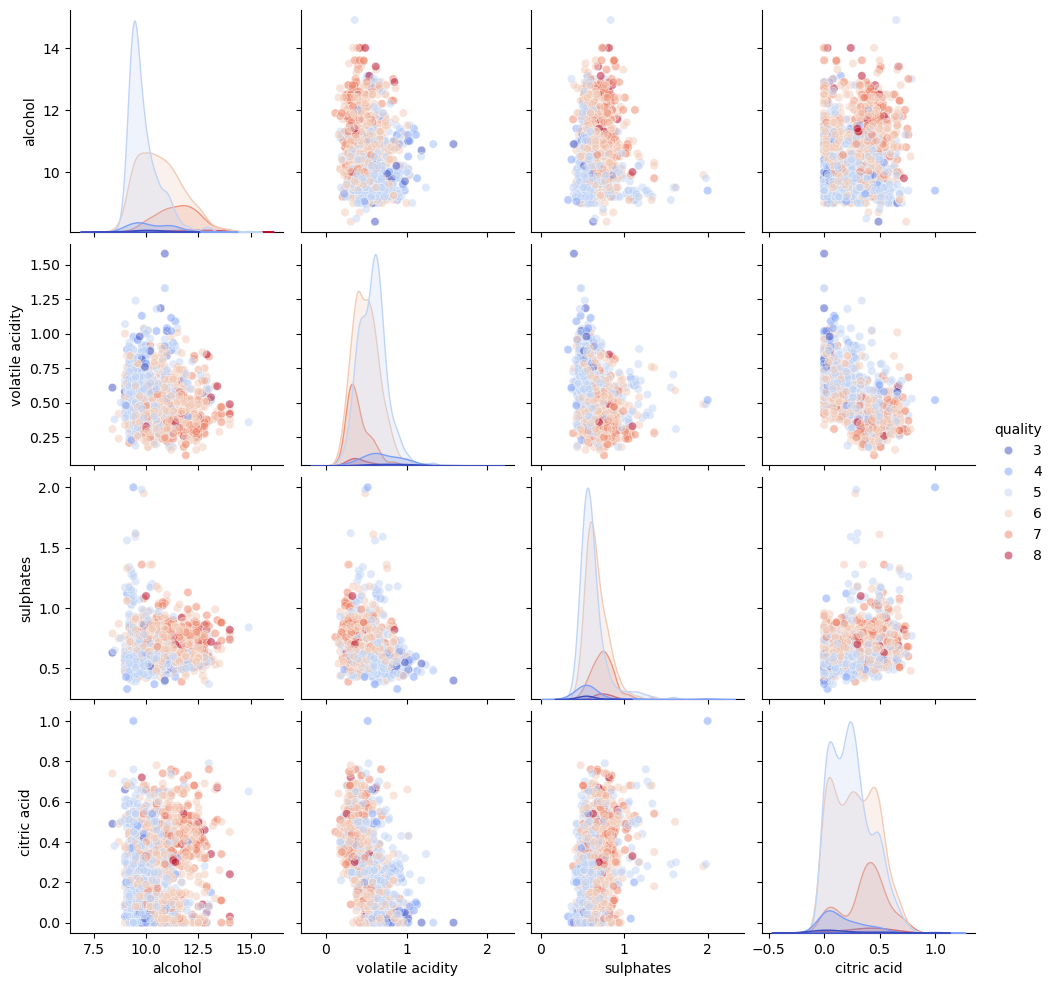

In [47]:
important = ["quality", "alcohol", "volatile acidity", "sulphates", "citric acid"]
sns.pairplot(df[important], hue="quality", palette="coolwarm", plot_kws={"alpha": 0.5})
plt.show()

##### This pairplot shows the relationship between important wine features. Higher-quality wines usually have higher alcohol, lower volatile acidity, and slightly higher sulphates and citric acid. The plot helps us see which features are more connected to better wine quality.

### Alcohol vs Volatile Acidity by Wine Quality

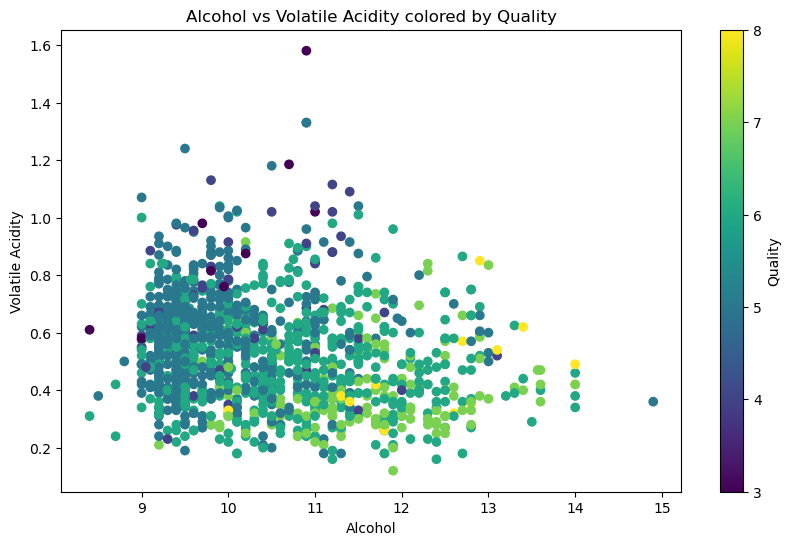

In [50]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["alcohol"], df["volatile acidity"],c=df["quality"])
plt.colorbar(scatter, label="Quality")
plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.title("Alcohol vs Volatile Acidity colored by Quality")
plt.show()

##### This scatter plot shows that better-quality wines usually have higher alcohol and lower volatile acidity. Wines with low quality are more often found when volatile acidity is high. This means alcohol can improve wine quality, while too much volatile acidity can reduce it.